# Customer Financial Metrics — Churn & Risk Analysis (EDA)

This notebook walks through the full pipeline: data cleaning, outlier treatment, exploratory data analysis, feature engineering, and churn comparison for a bank customer dataset.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Load the Dataset

In [2]:
url = "https://gitlab.crio.do/me_notebook/me_jupyter_bankattritionanalysis/-/raw/master/bank_dataset_v2.csv"
df = pd.read_csv(url, header=0, skiprows=[1])
df.head()


,Row Number,Customer ID,First Name,State,Gender,Age,Salary,Credit Score,Tenure,Balance,...,HasLoan,HasFD,Num Of Products,IsActiveMember,Exited,Complain,Count of Complains,Satisfaction Score,Point Earned,Preferred Channel
0,2,MH00002,Nitya,Maharashtra,Female,77,33000.0,538,4,0.00,...,0,0,1,0,1,0,0,5.0,100,Mobile
1,3,KA00003,Vivaan,Karnataka,Male,78,190000.0,531,8,15585.55,...,0,1,2,1,1,0,0,10.0,150,Mobile
2,4,MH00004,Dinesh,Maharashtra,Male,42,330000.0,718,3,155688.22,...,0,1,2,1,0,0,0,10.0,150,Phone
3,5,KA00005,Charvi,Karnataka,Female,29,155000.0,710,7,89415.53,...,0,1,2,1,0,0,0,4.0,90,Branch
4,6,DL00006,Aditi,Delhi,Female,38,111000.0,729,2,36613.80,...,1,0,2,1,0,0,0,4.0,90,Email


## 3. Standardize Column Names

Convert all column names to lowercase and replace spaces with underscores for consistency.

In [3]:
df.columns = df.columns.str.lower().str.replace(" ", "_")
df.columns


Index(['row_number', 'customer_id', 'first_name', 'state', 'gender', 'age',
       'salary', 'credit_score', 'tenure', 'balance', 'hascrcard', 'card_type',
       'hasloan', 'hasfd', 'num_of_products', 'isactivemember', 'exited',
       'complain', 'count_of_complains', 'satisfaction_score', 'point_earned',
       'preferred_channel'],
      dtype='str')

## 4. Handle Missing Values

In [4]:
# Check missing values before cleaning
df.isnull().sum()


row_number            0
customer_id           0
first_name            0
state                 0
gender                6
age                   0
salary                9
credit_score          0
tenure                0
balance               8
hascrcard             0
card_type             5
hasloan               0
hasfd                 0
num_of_products       0
isactivemember        0
exited                0
complain              0
count_of_complains    0
satisfaction_score    9
point_earned          0
preferred_channel     0
dtype: int64

In [5]:
# Impute numeric columns
df['salary'] = df['salary'].fillna(df['salary'].median())
df['balance'] = df['balance'].fillna(0)
df['satisfaction_score'] = df['satisfaction_score'].fillna(df['satisfaction_score'].median())

# Drop rows where a key categorical field is missing
df = df.dropna(subset=['gender'])

# Fill missing 'card_type' with the most frequent value (mode)
df['card_type'] = df['card_type'].fillna(df['card_type'].mode()[0])


In [6]:
# Check missing values after cleaning
df.isnull().sum()


row_number            0
customer_id           0
first_name            0
state                 0
gender                0
age                   0
salary                0
credit_score          0
tenure                0
balance               0
hascrcard             0
card_type             0
hasloan               0
hasfd                 0
num_of_products       0
isactivemember        0
exited                0
complain              0
count_of_complains    0
satisfaction_score    0
point_earned          0
preferred_channel     0
dtype: int64

## 5. Clean Up Text Columns

In [7]:
# Standardize 'card_type' formatting
df['card_type'] = df['card_type'].str.upper().str.strip()
df['card_type'].unique()


<StringArray>
['SILVER', 'GOLD', 'PLATINUM', 'NOT APPLICABLE']
Length: 4, dtype: str

## 6. Explore Numeric Columns

In [8]:
numeric_columns = df.select_dtypes(include='number').columns.tolist()
print("Numeric columns:", numeric_columns)

unique_counts = {col: df[col].nunique() for col in numeric_columns}
unique_counts


Numeric columns: ['row_number', 'age', 'salary', 'credit_score', 'tenure', 'balance', 'hascrcard', 'hasloan', 'hasfd', 'num_of_products', 'isactivemember', 'exited', 'complain', 'count_of_complains', 'satisfaction_score', 'point_earned']


{'row_number': 14993,
 'age': 56,
 'salary': 194,
 'credit_score': 435,
 'tenure': 10,
 'balance': 12660,
 'hascrcard': 2,
 'hasloan': 2,
 'hasfd': 2,
 'num_of_products': 4,
 'isactivemember': 2,
 'exited': 2,
 'complain': 2,
 'count_of_complains': 31,
 'satisfaction_score': 10,
 'point_earned': 74}

## 7. Outlier Detection and Treatment (Salary & Balance)

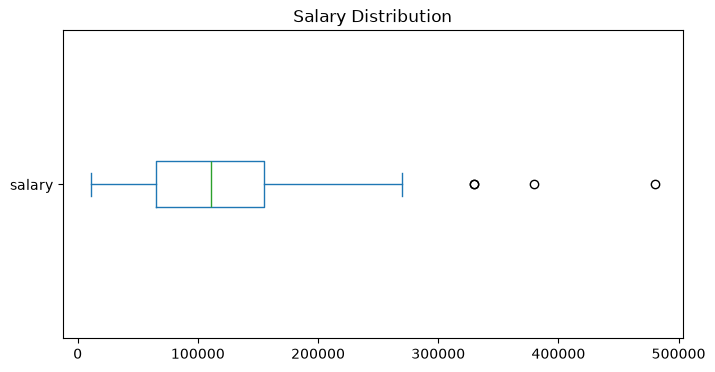

In [9]:
# Boxplot: Salary distribution before treatment
plt.figure(figsize=(8, 4))
df['salary'].plot(kind='box', vert=False)
plt.title('Salary Distribution')
plt.show()


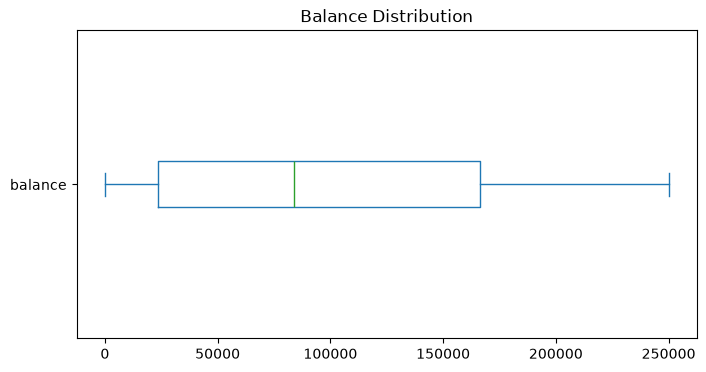

In [10]:
# Boxplot: Balance distribution
plt.figure(figsize=(8, 4))
df['balance'].plot(kind='box', vert=False)
plt.title('Balance Distribution')
plt.show()


In [11]:
# Identify outliers in 'salary' using the IQR method
Q1 = df['salary'].quantile(0.25)
Q3 = df['salary'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

salary_outliers = df[(df['salary'] < lower_bound) | (df['salary'] > upper_bound)]
print("Number of salary outliers:", len(salary_outliers))


Number of salary outliers: 4


In [12]:
# Cap salary outliers at the lower/upper bounds
df['salary'] = np.where(df['salary'] < lower_bound, lower_bound, df['salary'])
df['salary'] = np.where(df['salary'] > upper_bound, upper_bound, df['salary'])


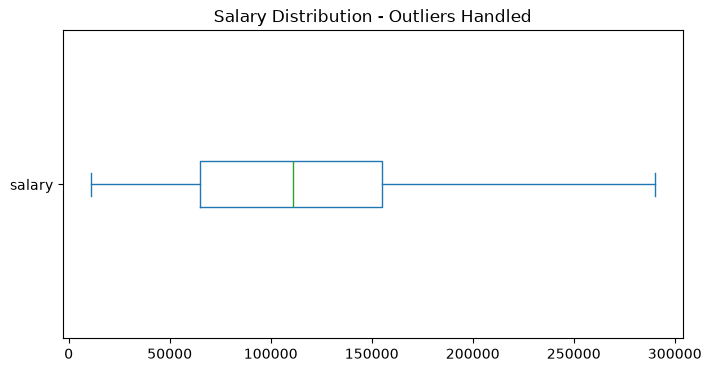

In [13]:
# Boxplot: Salary distribution after treatment
plt.figure(figsize=(8, 4))
df['salary'].plot(kind='box', vert=False)
plt.title('Salary Distribution - Outliers Handled')
plt.show()


## 8. Summary Statistics

In [14]:
summary = df[['salary', 'balance', 'credit_score']].agg(['mean', 'median'])
summary


,salary,balance,credit_score
mean,110152.404455,96957.788776,669.510105
median,111000.000000,84080.870000,683.000000


## 9. Categorical Variable Analysis

In [15]:
gender_count = df['gender'].value_counts()
card_type_count = df['card_type'].value_counts()
hasloan_count = df['hasloan'].value_counts()
hasfd_count = df['hasfd'].value_counts()

print("Gender:\n", gender_count)
print("\nCard Type:\n", card_type_count)
print("\nHas Loan:\n", hasloan_count)
print("\nHas FD:\n", hasfd_count)


Gender:
 gender
Male      9028
Female    5965
Name: count, dtype: int64

Card Type:
 card_type
SILVER            4366
GOLD              4033
PLATINUM          3398
NOT APPLICABLE    3196
Name: count, dtype: int64

Has Loan:
 hasloan
0    11520
1     3473
Name: count, dtype: int64

Has FD:
 hasfd
0    8355
1    6638
Name: count, dtype: int64


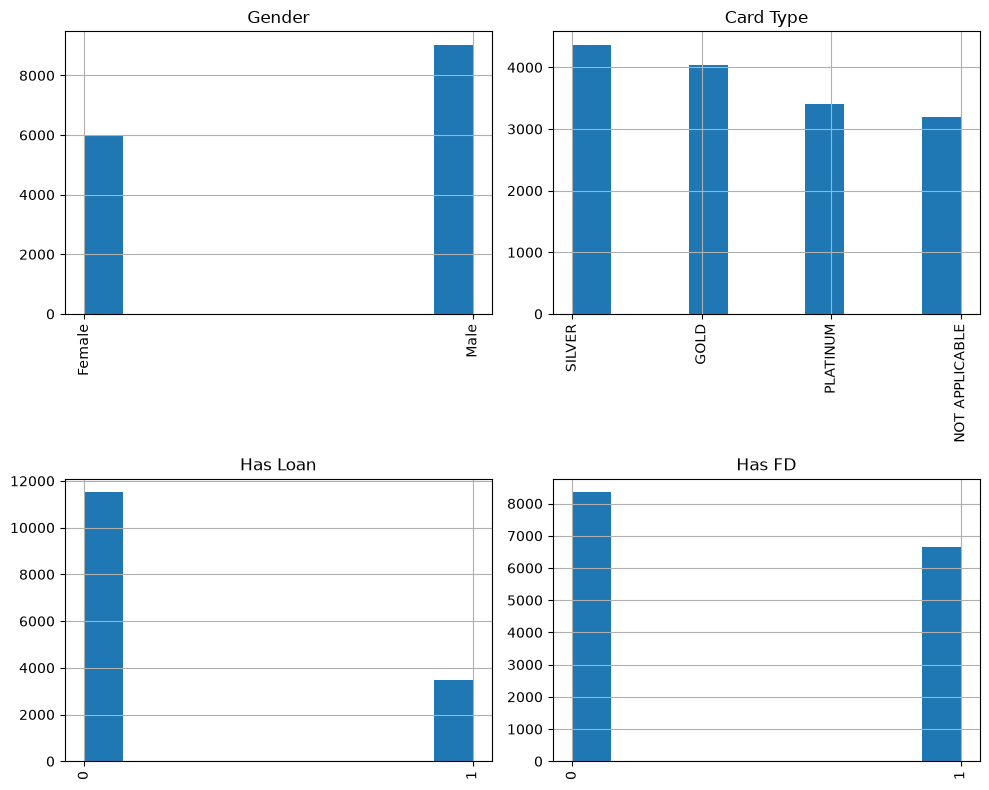

In [16]:
# Visualize categorical distributions
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

df['gender'].astype(str).hist(ax=axes[0, 0], xrot=90)
axes[0, 0].set_title('Gender')

df['card_type'].astype(str).hist(ax=axes[0, 1], xrot=90)
axes[0, 1].set_title('Card Type')

df['hasloan'].astype(str).hist(ax=axes[1, 0], xrot=90)
axes[1, 0].set_title('Has Loan')

df['hasfd'].astype(str).hist(ax=axes[1, 1], xrot=90)
axes[1, 1].set_title('Has FD')

fig.tight_layout()
plt.show()


## 10. Balance Distribution (Detailed View)

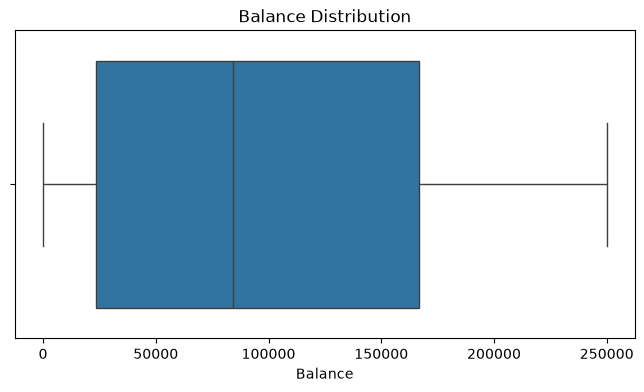

In [17]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['balance'])
plt.title('Balance Distribution')
plt.xlabel('Balance')
plt.show()


## 11. Bivariate Analysis: Credit Score vs Balance

Using a random sample of 200 customers to keep the scatter plot readable.

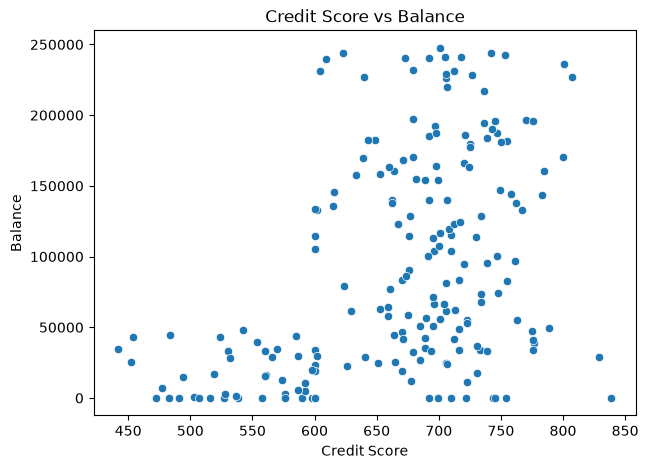

In [18]:
random_sample = df.sample(n=200, random_state=0).reset_index()

plt.figure(figsize=(7, 5))
sns.scatterplot(data=random_sample, x='credit_score', y='balance')
plt.xlabel('Credit Score')
plt.ylabel('Balance')
plt.title('Credit Score vs Balance')
plt.show()


## 12. Feature Engineering

- **Debt-to-Income Ratio** = (Balance + (HasLoan × Salary × 0.3)) / Salary
- **Loyalty Score** = (Tenure × Satisfaction Score) / (1 + Count of Complaints)

In [19]:
df['dti_ratio'] = (df['balance'] + (df['hasloan'] * df['salary'] * 0.3)) / df['salary']
df['loyalty_score'] = (df['tenure'] * df['satisfaction_score']) / (1 + df['count_of_complains'])

df[['balance', 'hasloan', 'salary', 'dti_ratio', 'tenure', 'satisfaction_score', 'loyalty_score']].head()


,balance,hasloan,salary,dti_ratio,tenure,satisfaction_score,loyalty_score
0,0.00,0,33000.0,0.000000,4,5.0,20.0
1,15585.55,0,190000.0,0.082029,8,10.0,80.0
2,155688.22,0,290000.0,0.536856,3,10.0,30.0
3,89415.53,0,155000.0,0.576874,7,4.0,28.0
4,36613.80,1,111000.0,0.629854,2,4.0,8.0


## 13. Complaints Analysis by State

In [20]:
# Average complaints per state
df['avg_complaints_state'] = df.groupby('state')['count_of_complains'].transform('mean')

# Flag customers whose complaints are above their state's average
df['high_complainer'] = (df['count_of_complains'] > df['avg_complaints_state']).astype(int)

df[['state', 'count_of_complains', 'avg_complaints_state', 'high_complainer']].head(10)


,state,count_of_complains,avg_complaints_state,high_complainer
0,Maharashtra,0,4.235927,0
1,Karnataka,0,4.297710,0
2,Maharashtra,0,4.235927,0
3,Karnataka,0,4.297710,0
4,Delhi,0,4.317580,0
5,Delhi,30,4.317580,1
6,Maharashtra,0,4.235927,0
7,Maharashtra,0,4.235927,0
8,West Bengal,0,4.188338,0
9,Tamil Nadu,0,4.055290,0


## 14. Univariate Analysis: Salary Categories

In [21]:
bins = [0, 50000, 100000, 150000, 200000, float('inf')]
labels = ['Low', 'Medium', 'High', 'Very High', 'Above 2 Lakhs']

df['salary_category'] = pd.cut(df['salary'], bins=bins, labels=labels)

salary_category_counts = df.groupby('salary_category')['customer_id'].count().reset_index()
salary_category_counts


,salary_category,customer_id
0,Low,2583
1,Medium,4070
2,High,4154
3,Very High,4180
4,Above 2 Lakhs,6


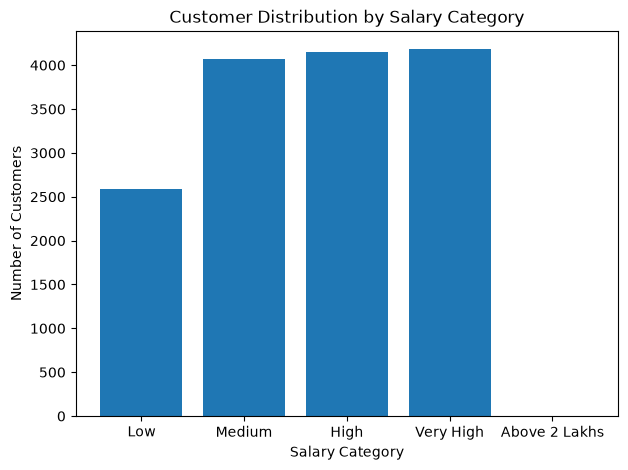

In [22]:
plt.figure(figsize=(7, 5))
plt.bar(salary_category_counts['salary_category'], salary_category_counts['customer_id'])
plt.title('Customer Distribution by Salary Category')
plt.xlabel('Salary Category')
plt.ylabel('Number of Customers')
plt.show()


## 15. Bivariate Analysis: Tenure vs Number of Products

In [23]:
avg_products_by_tenure = df.groupby('tenure')['num_of_products'].mean()
avg_products_by_tenure


tenure
1     1.433551
2     1.444779
3     1.437894
4     1.476880
5     1.495677
6     1.490417
7     1.368132
8     1.481707
9     1.511556
10    1.514377
Name: num_of_products, dtype: float64

## 16. Multivariate Analysis: Churn Comparison

Comparing salary and product usage between retained (0) and exited (1) customers.

In [24]:
churn_summary = df.groupby('exited')[['salary', 'num_of_products']].mean()
churn_summary


,salary,num_of_products
exited,,
0,115263.672522,1.509778
1,89064.273504,1.260171


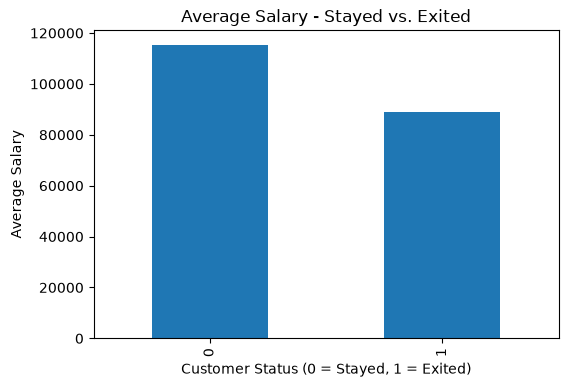

In [25]:
avg_salary = df.groupby('exited')['salary'].mean()

plt.figure(figsize=(6, 4))
avg_salary.plot(kind='bar')
plt.title('Average Salary - Stayed vs. Exited')
plt.xlabel('Customer Status (0 = Stayed, 1 = Exited)')
plt.ylabel('Average Salary')
plt.show()


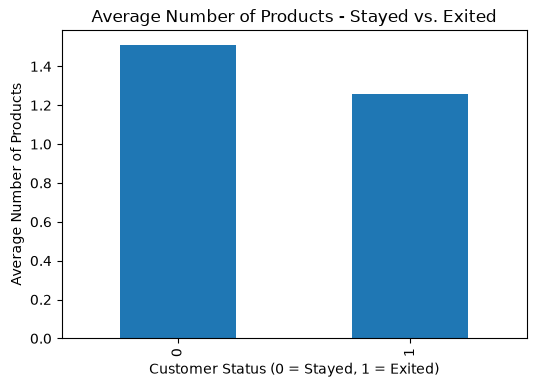

In [26]:
avg_products = df.groupby('exited')['num_of_products'].mean()

plt.figure(figsize=(6, 4))
avg_products.plot(kind='bar')
plt.title('Average Number of Products - Stayed vs. Exited')
plt.xlabel('Customer Status (0 = Stayed, 1 = Exited)')
plt.ylabel('Average Number of Products')
plt.show()
